In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import types
from tqdm.auto import tqdm

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import timm
from peft import LoraConfig
from peft.tuners.lora import LoraModel
from torch.utils.data import DataLoader, WeightedRandomSampler
from pathlib import Path
from tqdm.auto import tqdm
from collections import defaultdict
import sys, types
sys.path.append(".")
from src.dataset import HistologicalImageDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import torchvision.transforms as T

CFG = dict(
    data_dir  = "/data/BREAKHIS",
    img_size  = 224,
    batch_size= 64,
    num_workers=8,
    seed      = 42,
    output_dir= Path("checkpoints/uni_finetuned"),
)
torch.manual_seed(CFG["seed"]); np.random.seed(CFG["seed"])

train_tf = T.Compose([
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.RandomApply([T.RandomRotation((90,90))], p=0.5),
    T.RandomApply([T.ColorJitter(0.2,0.2,0.1,0.05)], p=0.5),
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])
eval_tf = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])

train_ds = HistologicalImageDataset(f"{CFG['data_dir']}/train", transform=train_tf)
val_ds   = HistologicalImageDataset(f"{CFG['data_dir']}/val",   transform=eval_tf)
test_ds  = HistologicalImageDataset(f"{CFG['data_dir']}/test",  transform=eval_tf)

counts  = np.bincount(train_ds.labels)
weights = torch.from_numpy((1.0/counts)[train_ds.labels]).double()
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

kw = dict(batch_size=CFG["batch_size"], num_workers=CFG["num_workers"],
          pin_memory=True, persistent_workers=True)
train_loader = DataLoader(train_ds, sampler=sampler, drop_last=True, **kw)
val_loader   = DataLoader(val_ds,  shuffle=False, **kw)
test_loader  = DataLoader(test_ds, shuffle=False, **kw)

CLASS_NAMES = train_ds.class_names
N_CLASSES   = len(CLASS_NAMES)
print(f"Classi: {CLASS_NAMES}")

Loading from /data/BREAKHIS/train...


Loading dataset from disk:   0%|          | 0/29 [00:00<?, ?it/s]

Loaded 25880 samples, 8 classes
Class distribution:
  adenosis: 1139 (4.4%)
  fibroadenoma: 3685 (14.2%)
  phyllodes_tumor: 1419 (5.5%)
  tubular_adenoma: 1642 (6.3%)
  ductal_carcinoma: 11717 (45.3%)
  lobular_carcinoma: 1927 (7.4%)
  mucinous_carcinoma: 2446 (9.5%)
  papillary_carcinoma: 1905 (7.4%)
Loading from /data/BREAKHIS/val...
Loaded 6832 samples, 8 classes
Class distribution:
  adenosis: 541 (7.9%)
  fibroadenoma: 692 (10.1%)
  phyllodes_tumor: 423 (6.2%)
  tubular_adenoma: 601 (8.8%)
  ductal_carcinoma: 2769 (40.5%)
  lobular_carcinoma: 601 (8.8%)
  mucinous_carcinoma: 757 (11.1%)
  papillary_carcinoma: 448 (6.6%)
Loading from /data/BREAKHIS/test...
Loaded 6833 samples, 8 classes
Class distribution:
  adenosis: 540 (7.9%)
  fibroadenoma: 693 (10.1%)
  phyllodes_tumor: 423 (6.2%)
  tubular_adenoma: 602 (8.8%)
  ductal_carcinoma: 2769 (40.5%)
  lobular_carcinoma: 602 (8.8%)
  mucinous_carcinoma: 757 (11.1%)
  papillary_carcinoma: 447 (6.5%)
Classi: ['adenosis', 'fibroadenoma',

In [4]:
class UNILoRAClassifier(nn.Module):
    def __init__(self, n_classes, dropout=0.1):
        super().__init__()
        backbone = timm.create_model(
            "hf-hub:MahmoodLab/uni", pretrained=True,
            init_values=1e-5, dynamic_img_size=True
        )
        lora_config = LoraConfig(
            r=8, lora_alpha=32,
            target_modules=["qkv","proj","fc1","fc2"],
            lora_dropout=0.1, bias="none"
        )
        self.backbone = LoraModel(backbone, lora_config, adapter_name="default")
        self.head = nn.Sequential(
            nn.LayerNorm(1024), nn.Dropout(dropout), nn.Linear(1024, n_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))

model = UNILoRAClassifier(N_CLASSES).to(device)
ckpt  = torch.load(CFG["output_dir"] / "best_model.pt", map_location=device)
missing, unexpected = model.load_state_dict(ckpt, strict=False)
print(f"Missing: {len(missing)} | Unexpected: {len(unexpected)}")
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

# Verifica rapida
with torch.no_grad():
    imgs, labs = next(iter(val_loader))
    acc = (model(imgs.to(device)).argmax(-1).cpu() == labs).float().mean()
print(f"Val batch accuracy: {acc:.3f}")

Missing: 0 | Unexpected: 0
Val batch accuracy: 0.938


In [5]:
class PatchAttacker(nn.Module):
    """
    Seleziona le N patch più dannose da rimuovere.
    
    Architettura:
    - Cross-patch Transformer: cattura dipendenze globali tra patch
    - CLS-aware scoring: condiziona lo score al CLS token (contesto semantico)
    - Gumbel-Softmax hard: selezione discreta differenziabile
    """
    def __init__(self, embed_dim=1024, n_patches=196,
                 hidden=512, n_heads=8, n_layers=2, dropout=0.1):
        super().__init__()
        self.n_patches  = n_patches
        self.embed_dim  = embed_dim

        # Proietta gli embedding in spazio più piccolo
        self.proj = nn.Linear(embed_dim, hidden)

        # Transformer leggero per catturare relazioni tra patch
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden, nhead=n_heads,
            dim_feedforward=hidden * 2,
            dropout=dropout, batch_first=True,
            norm_first=True,   # Pre-LN più stabile
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Scoring head — produce un logit per patch
        self.scorer = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, patch_embeddings, n_remove, temperature=0.5, hard=True):
        """
        patch_embeddings: [B, N, D]
        n_remove: quante patch rimuovere
        Ritorna:
            scores:    [B, N]   — importanza avversariale per patch
            soft_mask: [B, N]   — mask differenziabile (1=rimuovi)
            hard_mask: [B, N]   — mask binaria (usata nel forward)
        """
        B, N, D = patch_embeddings.shape
        x = self.proj(patch_embeddings)          # [B, N, hidden]
        x = self.transformer(x)                  # [B, N, hidden]
        scores = self.scorer(x).squeeze(-1)      # [B, N]

        # Gumbel-Softmax hard per selezione differenziabile
        # Usiamo il top-k con straight-through estimator
        gumbel_noise = -torch.empty_like(scores).exponential_().log()
        perturbed    = scores + gumbel_noise

        # Top-k threshold
        topk_vals  = perturbed.topk(n_remove, dim=-1).values
        threshold  = topk_vals[:, -1:]             # [B, 1]

        # Soft mask differenziabile
        soft_mask = torch.sigmoid((perturbed - threshold) / temperature)  # [B, N]

        # Hard mask (non differenziabile, usata per il forward reale)
        hard_mask = (scores >= scores.topk(n_remove, dim=-1).values[:, -1:]).float()

        # Straight-through: usa hard_mask nel forward, soft_mask per il gradiente
        if hard:
            mask = hard_mask - soft_mask.detach() + soft_mask
        else:
            mask = soft_mask

        return scores, mask, hard_mask


In [6]:
def get_patch_embeddings(model, imgs, device, layer_idx=8):
    """Estrae embedding patch al layer layer_idx. Ritorna [B, N-1, D]"""
    cache = {}
    orig  = {}

    def make_hook(idx):
        def fwd(self, x):
            B, N, C = x.shape
            qkv  = self.qkv(x).reshape(B,N,3,self.num_heads,self.head_dim).permute(2,0,3,1,4)
            q, k, v = qkv.unbind(0)
            q, k = self.q_norm(q), self.k_norm(k)
            attn = (q @ k.transpose(-2,-1) * self.scale).softmax(-1)
            if idx == layer_idx:
                cache['emb'] = x.detach()          # [B, N, D]
            x = (self.attn_drop(attn) @ v).transpose(1,2).reshape(B,N,C)
            return self.proj_drop(self.proj(x))
        return fwd

    for i, block in enumerate(model.backbone.model.blocks):
        orig[i] = block.attn.forward
        block.attn.forward = types.MethodType(make_hook(i), block.attn)

    with torch.no_grad():
        model(imgs.to(device))

    for i, block in enumerate(model.backbone.model.blocks):
        block.attn.forward = orig[i]

    return cache['emb'][:, 1:]   # escludi CLS → [B, N-1, D]

In [7]:
def apply_patch_mask(imgs, hard_mask, patch_size=16, n_side=14):
    """Versione differenziabile — usa moltiplicazione invece di assignment"""
    B = imgs.shape[0]
    # hard_mask: [B, 196] → [B, 1, 14, 14] → [B, 1, 224, 224]
    mask_2d = hard_mask.reshape(B, 1, n_side, n_side)
    mask_2d = mask_2d.repeat_interleave(patch_size, dim=2)\
                     .repeat_interleave(patch_size, dim=3)  # [B, 1, 224, 224]
    mask_2d = mask_2d.expand(-1, 3, -1, -1)                # [B, 3, 224, 224]
    
    return imgs * (1 - mask_2d)

In [8]:
def adversarial_loss(logits, labels, alpha_entropy=0.5):
    """
    Massimizza l'errore del modello:
    - Minimizza log-prob della classe corretta
    - Massimizza entropia dell'output (massima confusione)
    """
    log_probs = F.log_softmax(logits, dim=-1)
    probs     = log_probs.exp()

    # Termine 1: minimizza prob classe corretta
    correct_loss = log_probs[torch.arange(len(labels)), labels].mean()

    # Termine 2: massimizza entropia (rende il modello massimamente incerto)
    entropy = -(probs * log_probs).sum(-1).mean()

    # Vogliamo massimizzare correct_loss negativo + entropia
    loss = correct_loss - alpha_entropy * entropy
    return loss

In [9]:
def compute_tar_at_far(logits, labels, far_threshold=1e-4):
    probs          = F.softmax(logits, dim=-1)
    correct_scores = probs[torch.arange(len(labels)), labels].cpu().numpy()
    threshold      = np.quantile(correct_scores, far_threshold)
    tar            = (correct_scores > threshold).mean()
    return float(tar)

In [10]:
N_REMOVE     = 80
EMBED_LAYER  = 1
EPOCHS       = 30
TEMP_START   = 1.0
TEMP_END     = 0.1

attacker = PatchAttacker(embed_dim=1024, n_patches=196,
                         hidden=512, n_heads=8, n_layers=2).to(device)
opt  = torch.optim.AdamW(attacker.parameters(), lr=1e-4, weight_decay=0.01)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

model.eval()
for p in model.parameters():
    p.requires_grad_(False)


history_atk = {"loss": [], "fool_rate": [], "temp": [], "tar_drop": []}
for epoch in range(EPOCHS):
    attacker.train()
    temp = TEMP_START * (TEMP_END / TEMP_START) ** (epoch / max(EPOCHS-1, 1))
    total_loss, total_fooled, n_total = 0., 0, 0
    total_tar_drop = 0.

    for imgs, labels in tqdm(train_loader, leave=False):
        imgs_dev   = imgs.to(device)
        labels_dev = labels.to(device)

        emb = get_patch_embeddings(model, imgs_dev, device, EMBED_LAYER)
        scores, soft_mask, hard_mask = attacker(emb, N_REMOVE, temperature=temp)

        # Nel training loop — sostituisci il blocco reward con:
        with torch.no_grad():
            logits_orig   = model(imgs_dev)
            probs_orig    = F.softmax(logits_orig, dim=-1)
            masked_imgs   = apply_patch_mask(imgs_dev, hard_mask.detach())
            logits_masked = model(masked_imgs)

        # TAR@FAR=1e-4 originale vs dopo pruning
        tar_orig   = compute_tar_at_far(logits_orig,   labels_dev)
        tar_masked = compute_tar_at_far(logits_masked, labels_dev)

        # Reward = drop di TAR dopo pruning (vogliamo massimizzarlo)
        tar_drop = torch.tensor(tar_orig - tar_masked, dtype=torch.float32).to(device)
        tar_drop = tar_drop.expand(len(labels_dev))   # [B]

        scores_norm     = (scores - scores.mean(-1, keepdim=True)) / (scores.std(-1, keepdim=True) + 1e-8)
        selected_scores = (scores_norm * hard_mask.detach()).sum(-1) / N_REMOVE
        policy_loss     = -(tar_drop.detach() * selected_scores).mean()
        sparsity_reg    = ((soft_mask.sum(-1) - N_REMOVE) ** 2).mean()
        loss            = policy_loss + 0.1 * sparsity_reg

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(attacker.parameters(), 1.0)
        opt.step()

        fooled       = (logits_masked.argmax(-1) != labels_dev).sum().item()
        total_fooled += fooled
        total_loss   += loss.item() * len(labels)
        n_total      += len(labels)
        total_tar_drop += tar_drop.mean().item() * len(labels)

    
    
    sched.step()
    fool_rate = total_fooled / n_total
    history_atk["loss"].append(total_loss / n_total)
    history_atk["fool_rate"].append(fool_rate)
    history_atk["temp"].append(temp)
    history_atk["tar_drop"].append(total_tar_drop / n_total)


    # Fine epoca
    print(f"Epoch {epoch+1:02d} | loss={total_loss/n_total:.4f} "
        f"| fool_rate={fool_rate:.3f} | temp={temp:.3f} "
        f"| tar_drop={total_tar_drop/n_total:.4f}")

/home/oem/miniconda3/envs/trident/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  0%|          | 0/404 [00:00<?, ?it/s]

Epoch 01 | loss=0.0000 | fool_rate=0.034 | temp=1.000 | tar_drop=0.0000


  0%|          | 0/404 [00:00<?, ?it/s]

Epoch 02 | loss=0.0000 | fool_rate=0.038 | temp=0.924 | tar_drop=0.0000


...

Epoch 28 | loss=0.0000 | fool_rate=0.061 | temp=0.117 | tar_drop=0.0000


  0%|          | 0/404 [00:00<?, ?it/s]

Epoch 29 | loss=0.0000 | fool_rate=0.058 | temp=0.108 | tar_drop=0.0000


  0%|          | 0/404 [00:00<?, ?it/s]

Epoch 30 | loss=0.0000 | fool_rate=0.062 | temp=0.100 | tar_drop=0.0000


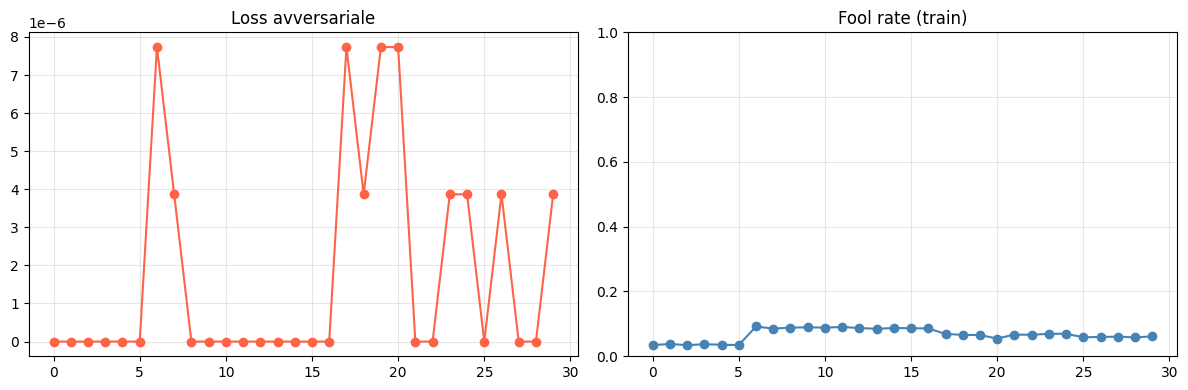

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_atk["loss"],      marker='o', color='tomato')
axes[0].set_title("Loss avversariale"); axes[0].grid(alpha=0.3)
axes[1].plot(history_atk["fool_rate"], marker='o', color='steelblue')
axes[1].set_title("Fool rate (train)"); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

In [12]:
attacker.eval()
model.eval()

fooled_atk, fooled_rnd, total_val = 0, 0, 0

for imgs, labels in tqdm(val_loader):
    imgs_dev = imgs.to(device)
    emb      = get_patch_embeddings(model, imgs_dev, device, EMBED_LAYER)

    with torch.no_grad():
        _, _, hard_mask = attacker(emb, N_REMOVE, temperature=0.01)

    # Attacker
    masked_atk = apply_patch_mask(imgs_dev, hard_mask)
    with torch.no_grad():
        preds_atk = model(masked_atk).argmax(-1).cpu()
    fooled_atk += (preds_atk != labels).sum().item()

    # Random baseline
    rnd_mask = torch.zeros_like(hard_mask)
    for b in range(len(labels)):
        idx = torch.randperm(196)[:N_REMOVE]
        rnd_mask[b, idx] = 1.
    masked_rnd = apply_patch_mask(imgs_dev, rnd_mask)
    with torch.no_grad():
        preds_rnd = model(masked_rnd).argmax(-1).cpu()
    fooled_rnd += (preds_rnd != labels).sum().item()

    total_val += len(labels)

print(f"\nVal fool rate — Attacker: {fooled_atk/total_val:.3f} "
      f"| Random: {fooled_rnd/total_val:.3f} "
      f"| Δ: {(fooled_atk-fooled_rnd)/total_val:+.3f}")
print(f"Patch rimosse: {N_REMOVE}/196 ({N_REMOVE/196*100:.1f}%)")



  0%|          | 0/107 [00:00<?, ?it/s]


Val fool rate — Attacker: 0.067 | Random: 0.060 | Δ: +0.006
Patch rimosse: 80/196 (40.8%)


/tmp/ipykernel_46112/799822245.py:32: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_46112/799822245.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/oem/miniconda3/envs/trident/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/oem/miniconda3/envs/trident/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


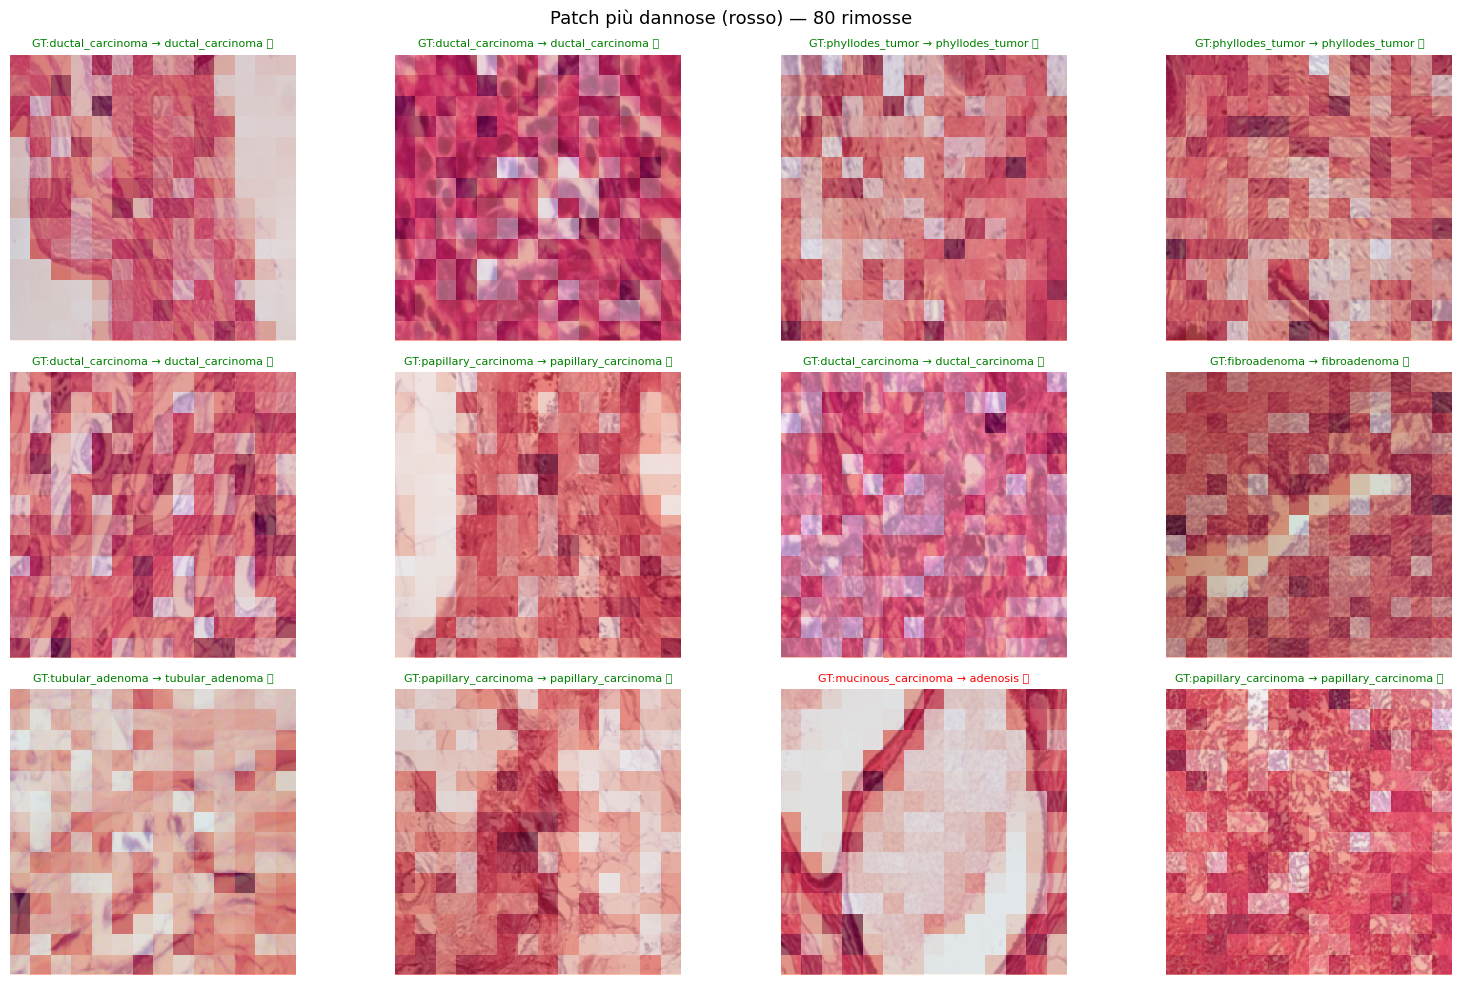

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for idx in range(12):
    ax  = axes[idx // 4, idx % 4]
    img, label = val_ds[idx]
    img_t = img.unsqueeze(0).to(device)

    emb = get_patch_embeddings(model, img_t, device, EMBED_LAYER)
    with torch.no_grad():
        scores, _, hard_mask = attacker(emb, N_REMOVE, temperature=0.01)

    score_map = scores[0].detach().cpu().reshape(14, 14).numpy()
    img_np    = img.permute(1,2,0).numpy()
    img_np    = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    ax.imshow(img_np)
    ax.imshow(score_map, cmap='Reds', alpha=0.6,
              extent=[0, 224, 224, 0], interpolation='nearest')

    masked = apply_patch_mask(img_t, hard_mask)
    with torch.no_grad():
        pred_orig   = model(img_t).argmax(-1).item()
        pred_masked = model(masked).argmax(-1).item()

    fooled = pred_masked != label.item()
    ax.set_title(f"GT:{CLASS_NAMES[label]} → {CLASS_NAMES[pred_masked]} "
                 f"{'✅' if fooled else '❌'}", fontsize=8,
                 color='red' if fooled else 'green')
    ax.axis('off')

plt.suptitle(f"Patch più dannose (rosso) — {N_REMOVE} rimosse", fontsize=13)
plt.tight_layout()
plt.show()